In [27]:
%matplotlib inline

import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import random

In [28]:
data_file_path = Path(os.getcwd()) / "names.txt"

lines = [] 
with open(data_file_path, "r", encoding="utf8") as f:
    lines = f.readlines()

names = [l.strip() for l in lines]

In [29]:
all_chars_unsorted = set([c for c in "".join(names)])
all_chars_unsorted.add(".")
possible_chars = sorted(all_chars_unsorted)

c_to_i = {c:i for i, c in enumerate(possible_chars)}
i_to_c = {i:c for i, c in enumerate(possible_chars)}

def char_to_int(c: str) -> int:
    return c_to_i[c]

def int_to_char(i: int) -> str:
    return i_to_c[i]

def context_to_str(l: list) -> str:
    return "".join([int_to_char(elem) for elem in l])

In [30]:
context_size = 3

def build_dataset(words: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
    X = []
    Y = []

    for name in words:
        context = [0] * context_size

        #print(name)
        for ch in name + ".":
            X.append(context)
            Y.append(char_to_int(ch))
            
            #print(f"{context_to_str(context)} ---> {ch}")
            context = context[1:] + [char_to_int(ch)]

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    return X, Y

random.shuffle(names)
dataset_size = len(names)
interval1 = int(0.8 * dataset_size)
interval2 = int(0.9 * dataset_size)
print(f"Dataset size: {dataset_size}, interval 1: {interval1}, interval 2: {interval2}")

Xtr, Ytr = build_dataset(names[:interval1])
Xdev, Ydev = build_dataset(names[interval1:interval2])
Xval, Yval = build_dataset(names[interval2:])


Dataset size: 32033, interval 1: 25626, interval 2: 28829


In [ ]:
# Linear layer
class Linear:
    def __init__(self, fan_in: int, fan_out: int, bias: bool = True):
        self.weights = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
        self.bias = torch.randn(fan_out) if bias else None
        self.out: torch.Tensor | None = None

    def __call__(self, input_tensor: torch.Tensor) -> torch.Tensor:
        self.out = input_tensor @ self.weights
        if self.bias is not None:
            self.out += self.bias

        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.weights] + [] if self.bias is None else [self.bias]

# tanh layer
class Tanh:
    def __init__(self):
        self.out: torch.Tensor | None = None

    def __call__(self, input_tensor: torch.Tensor):
        self.out = torch.tanh(input_tensor)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []

# Batchnorm layer
class BatchNorm1D:
    def __init__(
            self,
            num_features: int,
            eps: float = 1e-05,
            momentum: float = 0.001):
        self.bngain: torch.Tensor = torch.ones(num_features)
        self.bnbias: torch.Tensor = torch.zeros(num_features)
        self.bnmean_running: torch.Tensor = torch.zeros(num_features)
        self.bnstd_running: torch.Tensor = torch.ones(num_features)
        self.eps = eps
        self.momentum = momentum

        self.training: bool = True
        self.out: torch.Tensor | None = None

    def __call__(self, input_tensor: torch.Tensor) -> torch.Tensor:
        if self.training:
            bnmean = input_tensor.mean(0, keepdim=True)
            bnstd = input_tensor.std(0, keepdim=True)
        else:
            bnmean = self.bnmean_running
            bnstd = self.bnstd_running
        self.out = self.bngain * ((input_tensor - bnmean) / (bnstd + self.epsilon)) + self.bnbias

        if self.training:
            with torch.no_grad():
                self.bnmean_running = (1 - self.momentum) * self.bnmean_running + self.momentum * bnmean
                self.bnstd_running = (1 - self.momentum) * self.bnstd_running + self.momentum * bnstd

        return self.out

    def parameters(self):
        return [self.bngain, self.bnbias]

# Embedding layer
class Embedding:
    def __init__(self, fan_in: int, fan_out: int):
        self.emb: torch.Tensor = torch.randn((fan_in, fan_out))
        self.out: torch.Tensor | None = None

    def __call__(self, input: torch.Tensor) -> torch.Tensor:
        self.out = self.emb[input]
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.emb]

# Flatten layer
class Flatten:
    def __init__(self):
        self.out: torch.Tensor | None = None

    def __call__(self, input_tensor: torch.Tensor) -> torch.Tensor:
        self.out = input_tensor.view(input_tensor.shape[0], -1)
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []
        

In [32]:
n_emb = 10
n_hidden = 200
vocab_size = len(possible_chars)

#torch.manual_seed(42)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_emb), generator=g)
kaiming = ((5 / 3) / ((context_size * n_emb) ** 0.5))
print(f"Kaiming value: {kaiming}")
W1 = torch.randn((context_size * n_emb, n_hidden), generator=g) * kaiming
b1 = torch.randn(n_hidden, generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))
epsilon = 1e-5

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
num_of_parameters = sum((p.nelement() for p in parameters))
print(f"Num of parameters: {num_of_parameters}")
for p in parameters:
    p.requires_grad = True

Kaiming value: 0.3042903097250923
Num of parameters: 12297


In [33]:
@torch.no_grad()
def evaluate_nn(input_data, expected_data):
    emb = C[input_data]
    hpreact = emb.view(-1, W1.shape[0]) @ W1 + b1
    hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running + epsilon)) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, expected_data)
    print(f"Loss is: {loss}")

In [34]:
max_steps = 200000
batch_size = 32
stepi = []
lossi = []

for i in range(max_steps):
    indices = torch.randint(low=0, high=Xtr.shape[0], size=(batch_size, ))
    Xb = Xtr[indices]
    Yb = Ytr[indices]
    emb = C[Xb]
    hpreact = emb.view(-1, W1.shape[0]) @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
    hpreact = bngain * ((hpreact - bnmean) / (bnstd + epsilon)) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstd

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()
    stepi.append(i)
    lossi.append(loss.log10().item())

    learning_rate = 0.1 if i < 100000 else 0.01
    with torch.no_grad():
        for p in parameters:
            p -= learning_rate * p.grad

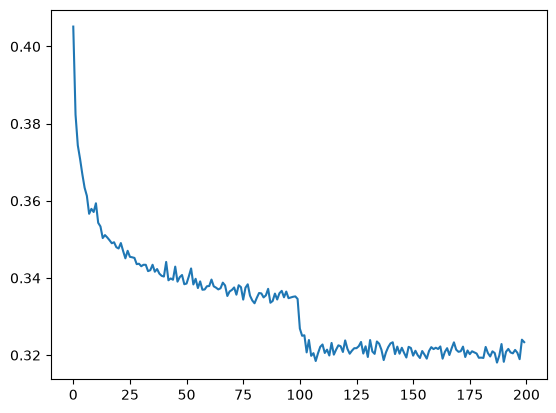

In [37]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [13]:
# NN loss evaluation
print("Dev data")
evaluate_nn(Xdev, Ydev)

print("Validation data")
evaluate_nn(Xval, Yval)

Dev data
Loss is: 2.12060546875
Validation data
Loss is: 2.1117334365844727


In [17]:
# Sample from the model
num_of_samples = 20

for _ in range(num_of_samples):
    name = []
    context = [0] * context_size

    while True:
        emb = C[context]
        hpreact = emb.view(-1, W1.shape[0]) @ W1 + b1
        hpreact = bngain * ((hpreact - bnmean_running) / (bnstd_running + epsilon)) + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probabilities = logits.softmax(1)
        next_char = torch.multinomial(probabilities, num_samples=1, generator=g).item()
        if next_char == 0:
            break

        name.append(int_to_char(next_char))
        context = context[1:] + [next_char]

    
    print("".join(name))

brayce
yoanna
ode
taretiel
jomi
naiaii
bisat
naleuko
aabranceoneelynn
deejaifira
alyn
kezas
jowsbeth
danil
vica
giorrentan
jah
coniyah
evaya
zachidaleraiyah
